In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer
!pip install contractions
import contractions
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
!pip install gensim
from gensim.models import word2vec
import gradio as gr
from tensorflow.keras.models import load_model
import pickle
from gensim.models import Word2Vec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 51.5 MB/s eta 0:00:00


### Text Preprocessing, Tokenization, and Sequence Padding

<b> Load the dataset

In [5]:
data = pd.read_csv("/content/drive/MyDrive/AI/Task_3/financial_phrase.csv")
data.head()

,text,label
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive


<b> Clean the text

In [6]:
data_cleaning = data["text"].dropna()

In [7]:
def lower_order(text):
    small_order_text = text.lower()
    return small_order_text

In [8]:
def remove_urls(text):
    url_pattern = re.compile(r'http\S+|www\S+|@\w+|#\w+|\d+')
    return url_pattern.sub(r'', text)

In [9]:
def handle_contractions(text):
    contraction_fixed_text = contractions.fix(text)
    return contraction_fixed_text

In [37]:
def remove_emoji(string):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"
                           u"\U0001F300-\U0001F5FF"
                           u"\U0001F680-\U0001F6FF"
                           u"\U0001F1E0-\U0001F1FF"
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r' ', string)

In [11]:
def remove_punct(text):
    tokenizer = RegexpTokenizer(r"\w+")
    tokens = tokenizer.tokenize(text)
    return ' '.join(tokens)

In [12]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def remove_stopwords(text_tokens):
    result_tokens = []
    for token in text_tokens:
        if token not in stop_words:
            result_tokens.append(token)
    return result_tokens

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [13]:
def lemmatization(token_text):
    lemma_tokens = []
    wordnet = WordNetLemmatizer()
    lemmatized_tokens = [wordnet.lemmatize(token, pos = 'v') for token in token_text]
    return lemmatized_tokens

In [38]:
def text_cleaning_pipeline(dataset):
    data = lower_order(dataset)

    data = remove_urls(data)

    data = handle_contractions(data)

    data = remove_emoji(data)

    data = remove_punct(data)

    tokens = data.split()

    tokens = remove_stopwords(tokens)

    tokens = lemmatization(tokens)

    return " ".join(tokens)

In [42]:
import nltk
nltk.download('wordnet')
sample = "Hello World? 😂 mgaoimtgoairtmb atrnbotb atrobia @##OI "
print(text_cleaning_pipeline(sample))

hello world mgaoimtgoairtmb atrnbotb atrobia


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [43]:
nltk.download('wordnet')
def lemmatization(token_text):
    lemma_tokens = []
    wordnet = WordNetLemmatizer()
    lemmatized_tokens = [wordnet.lemmatize(token, pos = 'v') for token in token_text]
    return lemmatized_tokens

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [44]:
test = data["text"][0]
print(text_cleaning_pipeline(test))

accord gran company plan move production russia although company grow


In [45]:
cleaned_tokens = data["text"].apply(lambda dataset: text_cleaning_pipeline(dataset))

In [46]:
data['cleaned_text'] = data['text'].apply(lambda dataset: text_cleaning_pipeline(dataset))

<b> Visualize the cleaned data:

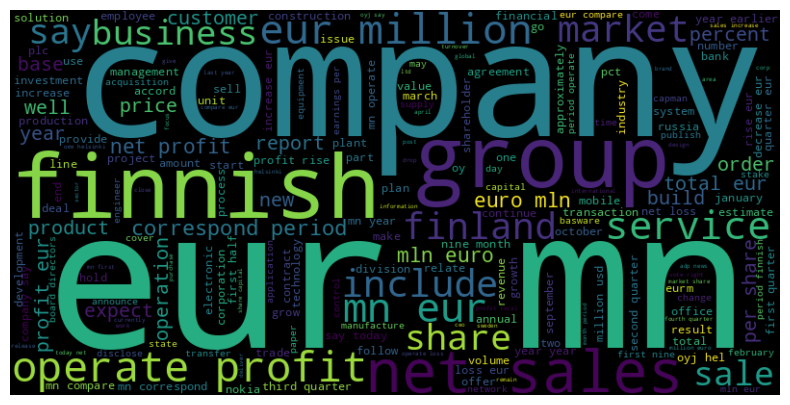

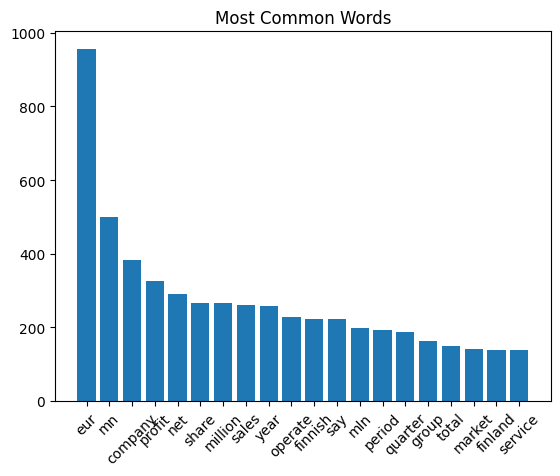

In [47]:
all_words = ' '.join(data['cleaned_text'])
wordcloud = WordCloud(width=800, height=400).generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

word_freq = Counter(all_words.split())
common_words = word_freq.most_common(20)

plt.bar(*zip(*common_words))
plt.title('Most Common Words')
plt.xticks(rotation=45)
plt.show()

In [48]:
print(data.columns)

Index(['text', 'label', 'cleaned_text'], dtype='object')


<b> Tokenization and Padding:

In [49]:
X = data['cleaned_text'].values
y = data['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

vocab_size = len(tokenizer.word_index) + 1

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Percentile-based padding
lengths = [len(seq) for seq in X_train_seq]
max_len = int(np.percentile(lengths, 95))

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

# Initialize and fit LabelEncoder
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

# Now use to_categorical
y_train_encoded = to_categorical(y_train_enc)
y_test_encoded = to_categorical(y_test_enc)

# Vocabulary size
vocab_size = len(tokenizer.word_index) + 1

<b> Simple RNN Model Building and Training

In [27]:
model1 = Sequential()
model1.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len))
model1.add(SimpleRNN(units=64, return_sequences=False))
model1.add(Dense(units=y_train_encoded.shape[1], activation='softmax'))

model1.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


<b> LSTM Model Building and Training:

In [28]:
model2 = Sequential()
model2.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len))
model2.add(LSTM(units=64, return_sequences=False))
model2.add(Dense(units=y_train_encoded.shape[1], activation='softmax'))

model2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

<b> LSTM with pretrained Word2Vec embeddings Model Building and Training:

In [50]:
embedding_dim = 300

# Prepare tokenized text corpus
tokenized_text = [text.split() for text in data['cleaned_text']]

# Train Word2Vec model
w2v_model = Word2Vec(sentences=tokenized_text, vector_size=embedding_dim, window=5, min_count=1)

# Create the embedding matrix
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]


model3 = Sequential()
model3.add(Embedding(input_dim=vocab_size,
                     output_dim=embedding_dim,
                     input_length=max_len,
                     weights=[embedding_matrix],
                     trainable=False))  #embeddings frozen
model3.add(LSTM(units=64, return_sequences=False))
model3.add(Dense(units=y_train_encoded.shape[1], activation='softmax'))

model3.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


<b> Simple RNN Model Training

In [51]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history1 = model1.fit(X_train_pad, y_train_encoded, validation_split=0.2, epochs=10, batch_size=32, callbacks=[early_stop])

Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8432 - loss: 0.4042 - val_accuracy: 0.7658 - val_loss: 0.6036
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9344 - loss: 0.1920 - val_accuracy: 0.7741 - val_loss: 0.6955
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9634 - loss: 0.1143 - val_accuracy: 0.7190 - val_loss: 0.7566
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9841 - loss: 0.0640 - val_accuracy: 0.7686 - val_loss: 0.7183


<b> LSTM Model Training

In [31]:
history2 = model2.fit(X_train_pad, y_train_encoded, validation_split=0.2, epochs=10, batch_size=32, callbacks=[early_stop])

Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.6153 - loss: 0.9022 - val_accuracy: 0.6887 - val_loss: 0.7109
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7797 - loss: 0.5134 - val_accuracy: 0.7438 - val_loss: 0.5798
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8329 - loss: 0.3728 - val_accuracy: 0.7521 - val_loss: 0.6302
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8529 - loss: 0.3260 - val_accuracy: 0.7410 - val_loss: 0.6207
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8543 - loss: 0.2988 - val_accuracy: 0.7410 - val_loss: 0.6423


<b> LSTM with Word2Vec Model Training

In [52]:
history3 = model3.fit(X_train_pad, y_train_encoded, validation_split=0.2, epochs=10, batch_size=32, callbacks=[early_stop])

Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.6215 - loss: 0.9627 - val_accuracy: 0.5950 - val_loss: 0.9183
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.6395 - loss: 0.8544 - val_accuracy: 0.6529 - val_loss: 0.8276
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.6837 - loss: 0.7721 - val_accuracy: 0.6970 - val_loss: 0.7581


<b> Model Visualization

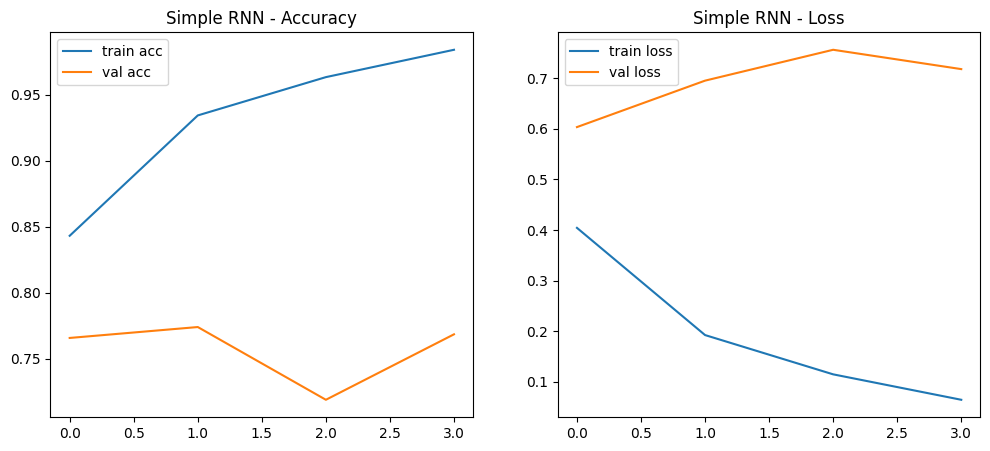

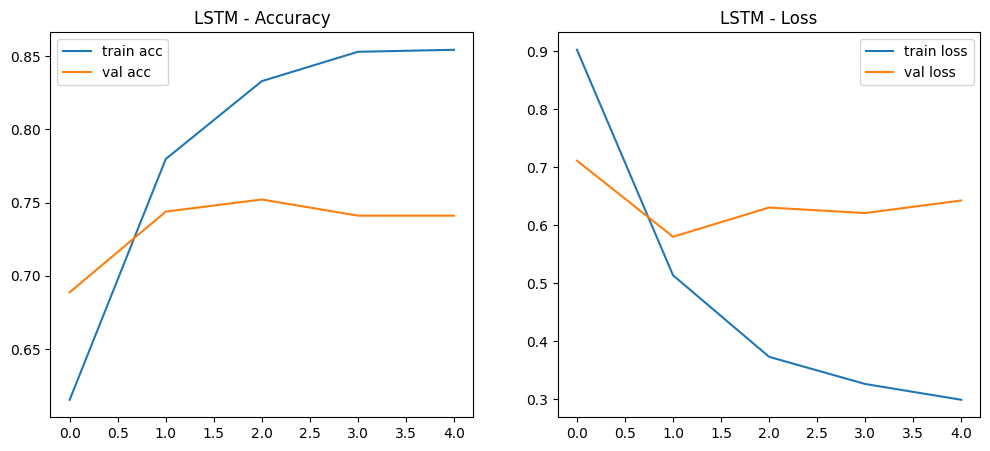

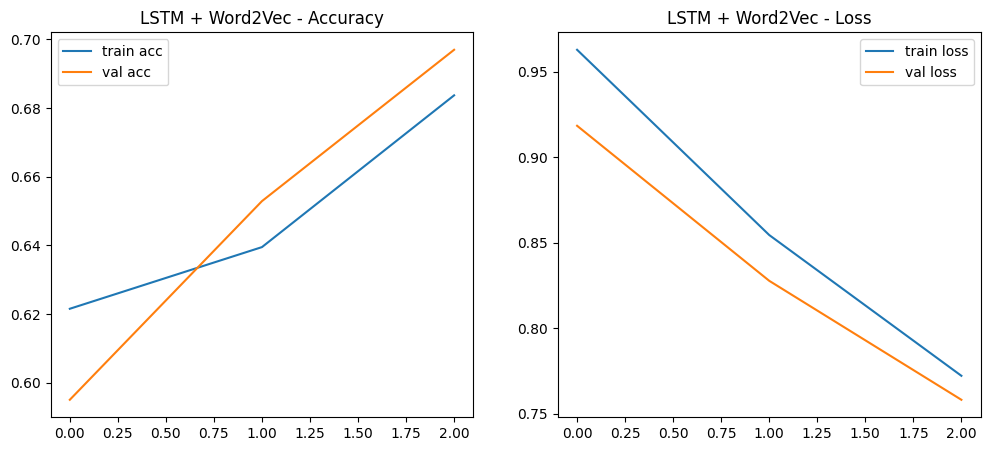

In [53]:
def plot_history(history, title):
    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='train acc')
    plt.plot(history.history['val_accuracy'], label='val acc')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='train loss')
    plt.plot(history.history['val_loss'], label='val loss')
    plt.title(f'{title} - Loss')
    plt.legend()

    plt.show()

plot_history(history1, "Simple RNN")
plot_history(history2, "LSTM")
plot_history(history3, "LSTM + Word2Vec")

<b> Model Evaluation

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.38      0.42        56
           1       0.85      0.96      0.90       276
           2       0.71      0.57      0.63       121

    accuracy                           0.79       453
   macro avg       0.68      0.64      0.65       453
weighted avg       0.77      0.79      0.77       453

Confusion Matrix:
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        56
           1       0.89      0.92      0.90       276
           2       0.58      0.80      0.67       121

    accuracy                           0.77       453
   macro avg       0.49      0.57      0.52       453
weighted avg       0.70      0.77      0.73       453

Confusion Matrix:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        56
           1       0.64      0.88      0.74       276
           2       0.37      0.23      0.28       121

    accuracy                           0.60       453
   macro avg       0.34      0.37      0.34       453
weighted avg       0.49      0.60      0.53       453

Confusion Matrix:


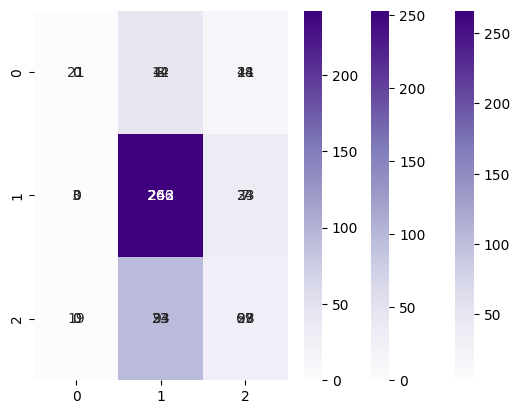

In [54]:
def evaluate_model(model, X_test_pad, y_test_encoded):
    y_pred = model.predict(X_test_pad)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_test_encoded, axis=1)

    print("Classification Report:\n", classification_report(y_true_classes, y_pred_classes))
    print("Confusion Matrix:")
    sns.heatmap(confusion_matrix(y_true_classes, y_pred_classes), annot=True, fmt='d', cmap='Purples')
evaluate_model(model1, X_test_pad, y_test_encoded)
evaluate_model(model2, X_test_pad, y_test_encoded)
evaluate_model(model3, X_test_pad, y_test_encoded)

In [55]:
# Save Model 1: Simple RNN
model1.save("model_rnn.keras")

# Save Model 2: LSTM
model2.save("model_lstm.keras")

# Save Model 3: LSTM + Word2Vec
model3.save("model_lstm_word2vec.keras")

# Save tokenizer
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

# Save label encoder
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

<b> GUI for Real Time Prediction

In [56]:
import pickle
import numpy as np
import gradio as gr
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ==============================
# Load trained models
# ==============================
model1 = load_model("model_rnn.keras")
model2 = load_model("model_lstm.keras")
model3 = load_model("model_lstm_word2vec.keras")

# ==============================
# Load tokenizer and label encoder
# ==============================
with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

with open("label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

# Same max length used during training
MAX_LEN = 50

# ==============================
# Text cleaning function
# ==============================
def text_cleaning_pipeline(text):
    text = text.lower()
    return text

# ==============================
# Preprocess input text
# ==============================
def preprocess_text(text):
    cleaned = text_cleaning_pipeline(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    return pad

# ==============================
# Prediction function
# ==============================
def predict_financial_sentiment(financial_text, model_choice):

    processed = preprocess_text(financial_text)

    # Select model
    if model_choice == "Simple RNN":
        prediction = model1.predict(processed)
    elif model_choice == "LSTM":
        prediction = model2.predict(processed)
    else:
        prediction = model3.predict(processed)

    pred_label = np.argmax(prediction, axis=1)[0]

    # If using label encoder:
    sentiment = label_encoder.inverse_transform([pred_label])[0]

    # Return user friendly output
    if sentiment.lower() == "negative":
        return "📉 Negative Financial Sentiment"
    elif sentiment.lower() == "neutral":
        return "📊 Neutral Financial Sentiment"
    else:
        return "📈 Positive Financial Sentiment"

# ==============================
# Gradio UI
# ==============================
iface = gr.Interface(
    fn=predict_financial_sentiment,
    inputs=[
        gr.Textbox(
            label="💬 Financial Phrase",
            lines=5,
            placeholder="Enter a financial sentence like: Company profits increased by 20%..."
        ),
        gr.Radio(
            choices=["Simple RNN", "LSTM", "LSTM with Word2Vec"],
            label="Choose Prediction Model"
        )
    ],
    outputs="text",
    title="💹 Financial Phrase Sentiment Detector 💹",
    description="This tool analyzes financial statements/news and predicts whether the sentiment is Positive, Neutral, or Negative.",
    theme="huggingface",
    css="""
        .container {
            background-color: #1E3A5F;
            color: white;
            border-radius: 10px;
        }
        .footer {
            display: none;
        }
        .gradio-container {
            background-color: #EAF2F8;
            border-radius: 15px;
            padding: 20px;
            font-family: Arial, sans-serif;
        }
        .gradio-button {
            background-color: #0B5ED7;
            color: white;
            border-radius: 5px;
            font-size: 16px;
        }
        .gradio-button:hover {
            background-color: #084298;
        }
        .gr-radio label {
            color: #062356;
            font-size: 18px;
        }
        .gr-textbox textarea {
            background-color: #ffffff;
            border-radius: 5px;
        }
    """
)

# ==============================
# Launch app
# ==============================
iface.launch()

/usr/local/lib/python3.12/dist-packages/gradio/blocks.py:1143: UserWarning: Cannot load huggingface. Caught Exception: Client error '404 Not Found' for url 'https://huggingface.co/api/spaces/huggingface' (Request ID: Root=1-69ff5eca-70a36c69079758a04960c601;062c8738-d654-4278-993a-afa53fdb1b48)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/404

Sorry, we can't find the page you are looking for.
  warnings.warn(f"Cannot load {theme}. Caught Exception: {str(e)}")


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://934c9c45eb4b142b64.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
